# Tugas Besar Deep Learning — Kasus 31
## Monitoring Kepatuhan PPE Kru Lapangan dengan YOLOv8n dan Optimasi Edge AI

**Kelompok 4** — Program Studi Sains Data, UPN "Veteran" Jawa Timur  
**Dosen pengampu:** Dr. I Gede Susrama Mas Diyasa, ST., MT.  
**Dosen praktisi:** Kahpi Baiquni Arifani, S.Kom., M.Kom.  
**Lingkungan:** Google Colab (GPU Tesla T4), Ultralytics 8.4.166, PyTorch 2.11. Sel dijalankan berurutan dari atas ke bawah, dan kami menyimpan artefak di Google Drive.

**Dataset:** Kaggle `waquarahmed1/ppe-dataset`  
**Format:** YOLO Object Detection  
**Kelas:** Helmet, Mask, Safety Vest, boots, glove  
**Split:** `train / val / test` sudah disediakan dataset dan tidak kami bagi ulang.



## 1. Instalasi dependensi


In [ ]:
!pip install -q -U kagglehub ultralytics pyyaml pandas matplotlib seaborn opencv-python-headless onnxruntime onnx


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires panda

## 2. Import dan konfigurasi


In [ ]:
import json
import time
import random
import shutil
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO

SEED = 42  # diterapkan pada Python, NumPy, dan PyTorch; parameter seed Ultralytics tidak diset (default 0)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"
HAS_GPU = torch.cuda.is_available()

IMG_SIZE = 640
EPOCHS = 50
BATCH_SIZE = 16 if HAS_GPU else 4
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50

MODEL_NAME = "yolov8n.pt"
RUN_NAME = "yolov8n_ppe_kaggle_kasus31"

print("PyTorch:", torch.__version__)
print("GPU tersedia:", HAS_GPU)
print("Device:", DEVICE)

# ===================== KONFIGURASI OPTIMASI =====================
RUN_INT8_EXPORT = True
RUN_PRUNING = True
PRUNE_AMOUNT = 0.30
PRUNE_FINETUNE_EPOCHS = 10
BENCHMARK_REPEATS = 20
BENCHMARK_WARMUP = 5


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
PyTorch: 2.11.0+cu128
GPU tersedia: True
Device: 0


## 3. Google Drive untuk hasil eksperimen

Dataset Kaggle tetap berada di `/content`. Kami hanya menyimpan output berikut ke Google Drive:

```text
runs/
models/
results/
samples/
```


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4")

RUNS_DIR = PROJECT_DIR / "runs_kaggle_ppe"
MODEL_DIR = PROJECT_DIR / "models_kaggle_ppe"
RESULTS_DIR = PROJECT_DIR / "results_kaggle_ppe"
SAMPLE_DIR = PROJECT_DIR / "samples_kaggle_ppe"

for folder in [PROJECT_DIR, RUNS_DIR, MODEL_DIR, RESULTS_DIR, SAMPLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4


## 4. Download dataset dengan KaggleHub

Kami mengambil dataset langsung dengan `kagglehub.dataset_download()` sehingga tidak perlu mengunggah `kaggle.json`. Dataset tetap berada pada storage runtime Colab.


In [ ]:
# Download dataset langsung dari KaggleHub
import kagglehub

dataset_path = kagglehub.dataset_download("waquarahmed1/ppe-dataset")
KAGGLE_ROOT = Path(dataset_path).resolve()

print("Path to dataset files:", KAGGLE_ROOT)


Using Colab cache for faster access to the 'ppe-dataset' dataset.
Path to dataset files: /kaggle/input/ppe-dataset


## 5. Baca struktur dataset

Dataset sudah berformat YOLO sehingga kami hanya perlu membaca `data.yaml` dan folder `train`, `val`, `test`. KaggleHub mengembalikan path lokal hasil unduhan melalui `dataset_download()`.


In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

yaml_files = list(KAGGLE_ROOT.rglob("data.yaml"))
if not yaml_files:
    raise FileNotFoundError("data.yaml tidak ditemukan.")

DATA_YAML_ORIGINAL = yaml_files[0].resolve()
DATA_CFG = yaml.safe_load(DATA_YAML_ORIGINAL.read_text(encoding="utf-8"))

print("data.yaml:", DATA_YAML_ORIGINAL)
print(DATA_YAML_ORIGINAL.read_text(encoding="utf-8"))


data.yaml: /kaggle/input/ppe-dataset/Dataset_no_person_glasses/data.yaml
path: /kaggle/input/datasets/waquarahmed1/ppe-dataset/Dataset_no_person_glasses
train: train/images
val: val/images
test: test/images
nc: 5
names:
- Helmet
- Mask
- Safety Vest
- boots
- glove



In [ ]:
# Baca nama kelas
names_raw = DATA_CFG.get("names", {})

if isinstance(names_raw, list):
    names = {i: str(v) for i, v in enumerate(names_raw)}
else:
    names = {int(k): str(v) for k, v in names_raw.items()}

print("Jumlah kelas:", len(names))
for idx, name in names.items():
    print(f"{idx}: {name}")

assert len(names) == 5, f"Diharapkan 5 kelas, tetapi terbaca {len(names)}."


Jumlah kelas: 5
0: Helmet
1: Mask
2: Safety Vest
3: boots
4: glove


In [ ]:
# Cari folder images untuk setiap split
def find_split(split):
    candidates = [
        DATA_YAML_ORIGINAL.parent / split / "images",
        DATA_YAML_ORIGINAL.parent / split,
        KAGGLE_ROOT / split / "images",
        KAGGLE_ROOT / split
    ]

    for path in candidates:
        if path.is_dir():
            image_count = sum(
                1 for p in path.rglob("*")
                if p.is_file() and p.suffix.lower() in IMG_EXTS
            )
            if image_count > 0:
                return path.resolve()

    for path in KAGGLE_ROOT.glob(f"**/{split}/images"):
        if path.is_dir():
            return path.resolve()

    return None

TRAIN_IMAGES = find_split("train")
VAL_IMAGES = find_split("val")
TEST_IMAGES = find_split("test")

print("TRAIN:", TRAIN_IMAGES)
print("VAL  :", VAL_IMAGES)
print("TEST :", TEST_IMAGES)

if TRAIN_IMAGES is None or VAL_IMAGES is None or TEST_IMAGES is None:
    raise RuntimeError("Folder train/val/test tidak lengkap.")


TRAIN: /kaggle/input/ppe-dataset/Dataset_no_person_glasses/train/images
VAL  : /kaggle/input/ppe-dataset/Dataset_no_person_glasses/val/images
TEST : /kaggle/input/ppe-dataset/Dataset_no_person_glasses/test/images


In [ ]:
# Buat runtime YAML dengan path absolut.
# Split tidak diubah; hanya path-nya dibuat eksplisit agar YOLO membacanya dengan aman.

RUNTIME_DATA_YAML = Path("/content/ppe_kaggle_runtime.yaml")

runtime_cfg = {
    "path": "/content",
    "train": str(TRAIN_IMAGES),
    "val": str(VAL_IMAGES),
    "test": str(TEST_IMAGES),
    "names": names,
    "nc": len(names)
}

RUNTIME_DATA_YAML.write_text(
    yaml.safe_dump(runtime_cfg, sort_keys=False, allow_unicode=True),
    encoding="utf-8"
)

DATA_YAML = RUNTIME_DATA_YAML

def count_images(folder):
    return sum(
        1 for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    )

split_counts = {
    "train": count_images(TRAIN_IMAGES),
    "val": count_images(VAL_IMAGES),
    "test": count_images(TEST_IMAGES)
}

total = sum(split_counts.values())

print("=== Split dataset ===")
for split, count in split_counts.items():
    pct = 100 * count / total if total else 0
    print(f"{split:5s}: {count:,} gambar ({pct:.2f}%)")

print("\nRuntime YAML:")
print(RUNTIME_DATA_YAML.read_text(encoding="utf-8"))


=== Split dataset ===
train: 8,243 gambar (69.99%)
val  : 2,357 gambar (20.01%)
test : 1,177 gambar (9.99%)

Runtime YAML:
path: /content
train: /kaggle/input/ppe-dataset/Dataset_no_person_glasses/train/images
val: /kaggle/input/ppe-dataset/Dataset_no_person_glasses/val/images
test: /kaggle/input/ppe-dataset/Dataset_no_person_glasses/test/images
names:
  0: Helmet
  1: Mask
  2: Safety Vest
  3: boots
  4: glove
nc: 5



## 6. EDA distribusi bounding box

Selain menghitung jumlah gambar per split, kami juga menghitung jumlah instance bounding box per kelas untuk memeriksa ketidakseimbangan kelas.


split,test,train,val
class,,,
Helmet,859,6172,1783
Mask,797,5967,1714
Safety Vest,638,4578,1393
boots,597,4739,1288
glove,860,5847,1700


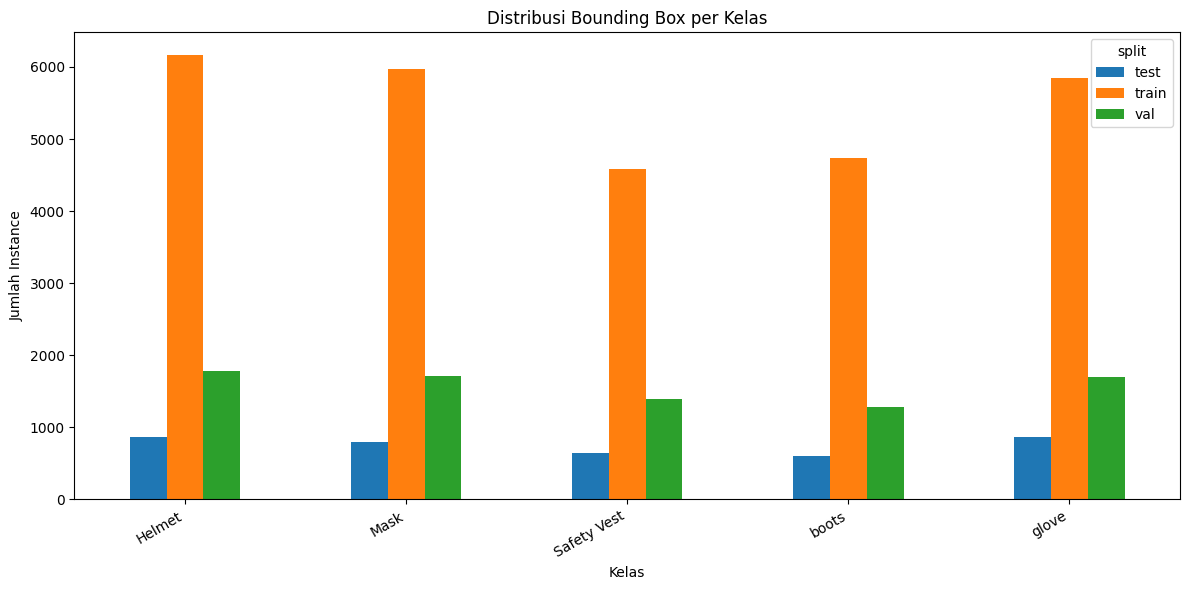

In [ ]:
def labels_dir(images_dir):
    return Path(images_dir).parent / "labels"

def read_classes(label_file):
    label_file = Path(label_file)
    if not label_file.exists():
        return []

    result = []
    for line in label_file.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) >= 5:
            try:
                result.append(int(parts[0]))
            except ValueError:
                pass
    return result

rows = []

for split, image_dir in {
    "train": TRAIN_IMAGES,
    "val": VAL_IMAGES,
    "test": TEST_IMAGES
}.items():

    counts = {i: 0 for i in names}
    label_dir = labels_dir(image_dir)

    for img in Path(image_dir).rglob("*"):
        if img.is_file() and img.suffix.lower() in IMG_EXTS:
            label_file = label_dir / f"{img.stem}.txt"
            for cls_id in read_classes(label_file):
                if cls_id in counts:
                    counts[cls_id] += 1

    for cls_id, count in counts.items():
        rows.append({
            "split": split,
            "class_id": cls_id,
            "class": names[cls_id],
            "instances": count
        })

dist_df = pd.DataFrame(rows)

display(
    dist_df.pivot(
        index="class",
        columns="split",
        values="instances"
    ).fillna(0).astype(int)
)

dist_pivot = dist_df.pivot(
    index="class",
    columns="split",
    values="instances"
).fillna(0)

ax = dist_pivot.plot(kind="bar", figsize=(12, 6))
ax.set_title("Distribusi Bounding Box per Kelas")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah Instance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. Visualisasi annotation


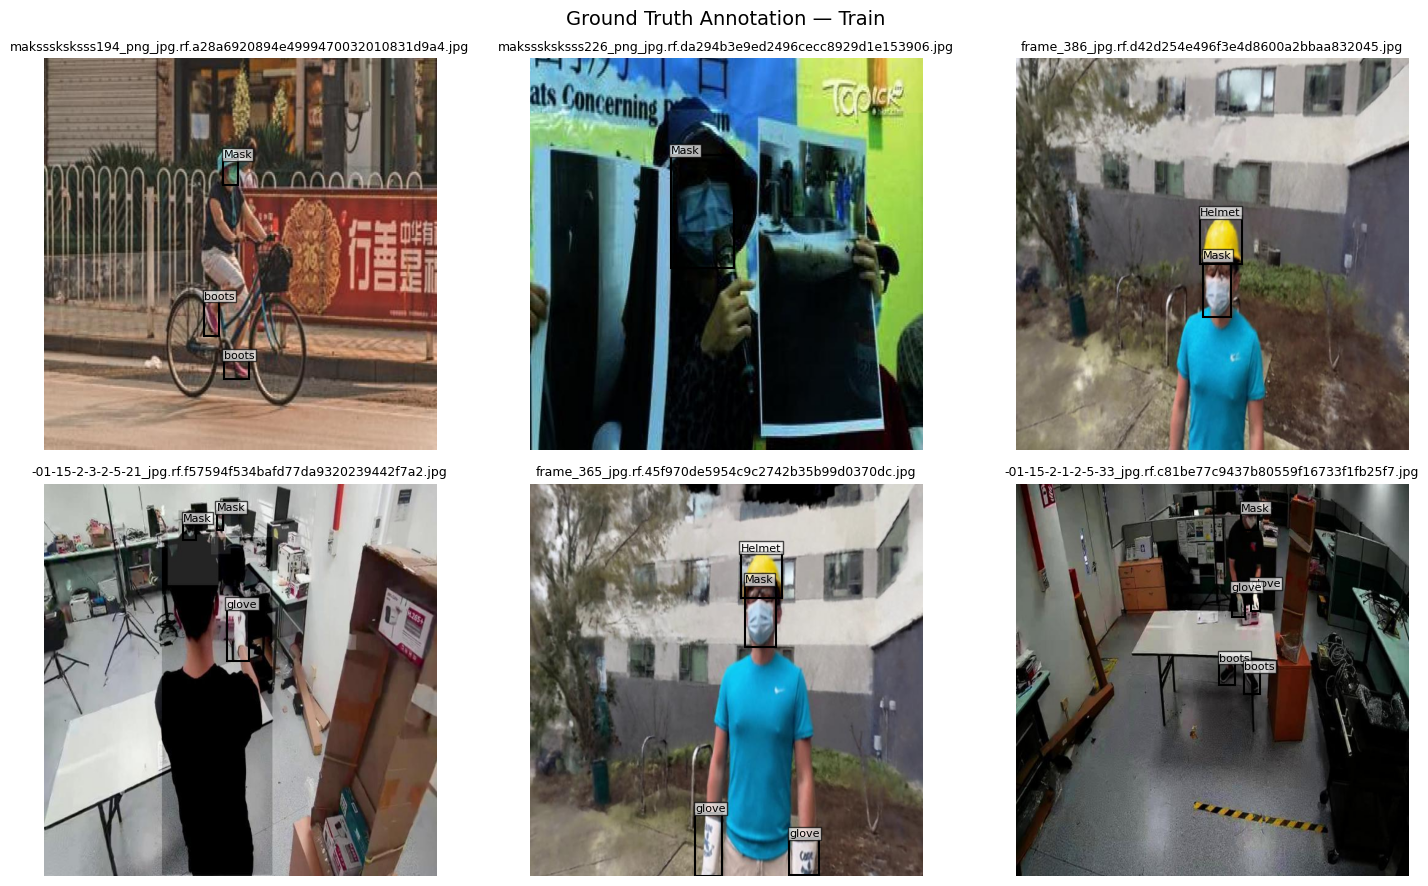

In [ ]:
def draw_gt(img_path, ax):
    img_path = Path(img_path)
    img = cv2.imread(str(img_path))

    if img is None:
        ax.axis("off")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=9)

    label_file = labels_dir(img_path.parent) / f"{img_path.stem}.txt"

    if not label_file.exists():
        return

    for line in label_file.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue

        cls_id = int(parts[0])
        xc, yc, bw, bh = map(float, parts[1:5])

        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        x2 = (xc + bw / 2) * w
        y2 = (yc + bh / 2) * h

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

        ax.text(
            x1,
            max(0, y1 - 2),
            names[cls_id],
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7, pad=1)
        )

train_pool = [
    p for p in TRAIN_IMAGES.rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

sample_gt = random.sample(train_pool, min(6, len(train_pool)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = np.array(axes).reshape(-1)

for ax, img_path in zip(axes, sample_gt):
    draw_gt(img_path, ax)

for ax in axes[len(sample_gt):]:
    ax.axis("off")

plt.suptitle("Ground Truth Annotation — Train", fontsize=14)
plt.tight_layout()
plt.show()


## 8. Load YOLOv8n

Kami memuat YOLOv8n pralatih melalui `YOLO("yolov8n.pt")`, lalu melatihnya pada dataset kustom dengan `model.train()`. Ultralytics juga menyediakan evaluasi, prediksi, dan ekspor [10].


In [ ]:
PRETRAINED_DRIVE = MODEL_DIR / "yolov8n.pt"

if PRETRAINED_DRIVE.exists():
    model = YOLO(str(PRETRAINED_DRIVE))
else:
    model = YOLO(MODEL_NAME)
    local_model = Path(MODEL_NAME)

    if local_model.exists():
        shutil.copy2(local_model, PRETRAINED_DRIVE)

print("Model:", MODEL_NAME)


Model: yolov8n.pt


## 9. Training YOLOv8n


In [ ]:
train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=2,
    patience=10,
    pretrained=True,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    verbose=True
)

TRAIN_RUN_DIR = Path(train_results.save_dir)

BEST_PT = TRAIN_RUN_DIR / "weights" / "best.pt"
LAST_PT = TRAIN_RUN_DIR / "weights" / "last.pt"

FINAL_BEST = MODEL_DIR / "ppe_yolov8n_kaggle_best.pt"
FINAL_LAST = MODEL_DIR / "ppe_yolov8n_kaggle_last.pt"

if BEST_PT.exists():
    shutil.copy2(BEST_PT, FINAL_BEST)

if LAST_PT.exists():
    shutil.copy2(LAST_PT, FINAL_LAST)

print("Training dir:", TRAIN_RUN_DIR)
print("Best model:", FINAL_BEST)
print("Last model:", FINAL_LAST)


Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_kaggle_runtime.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_ppe_kaggle_kasus31, nbs=64, nms=None, opset=None,

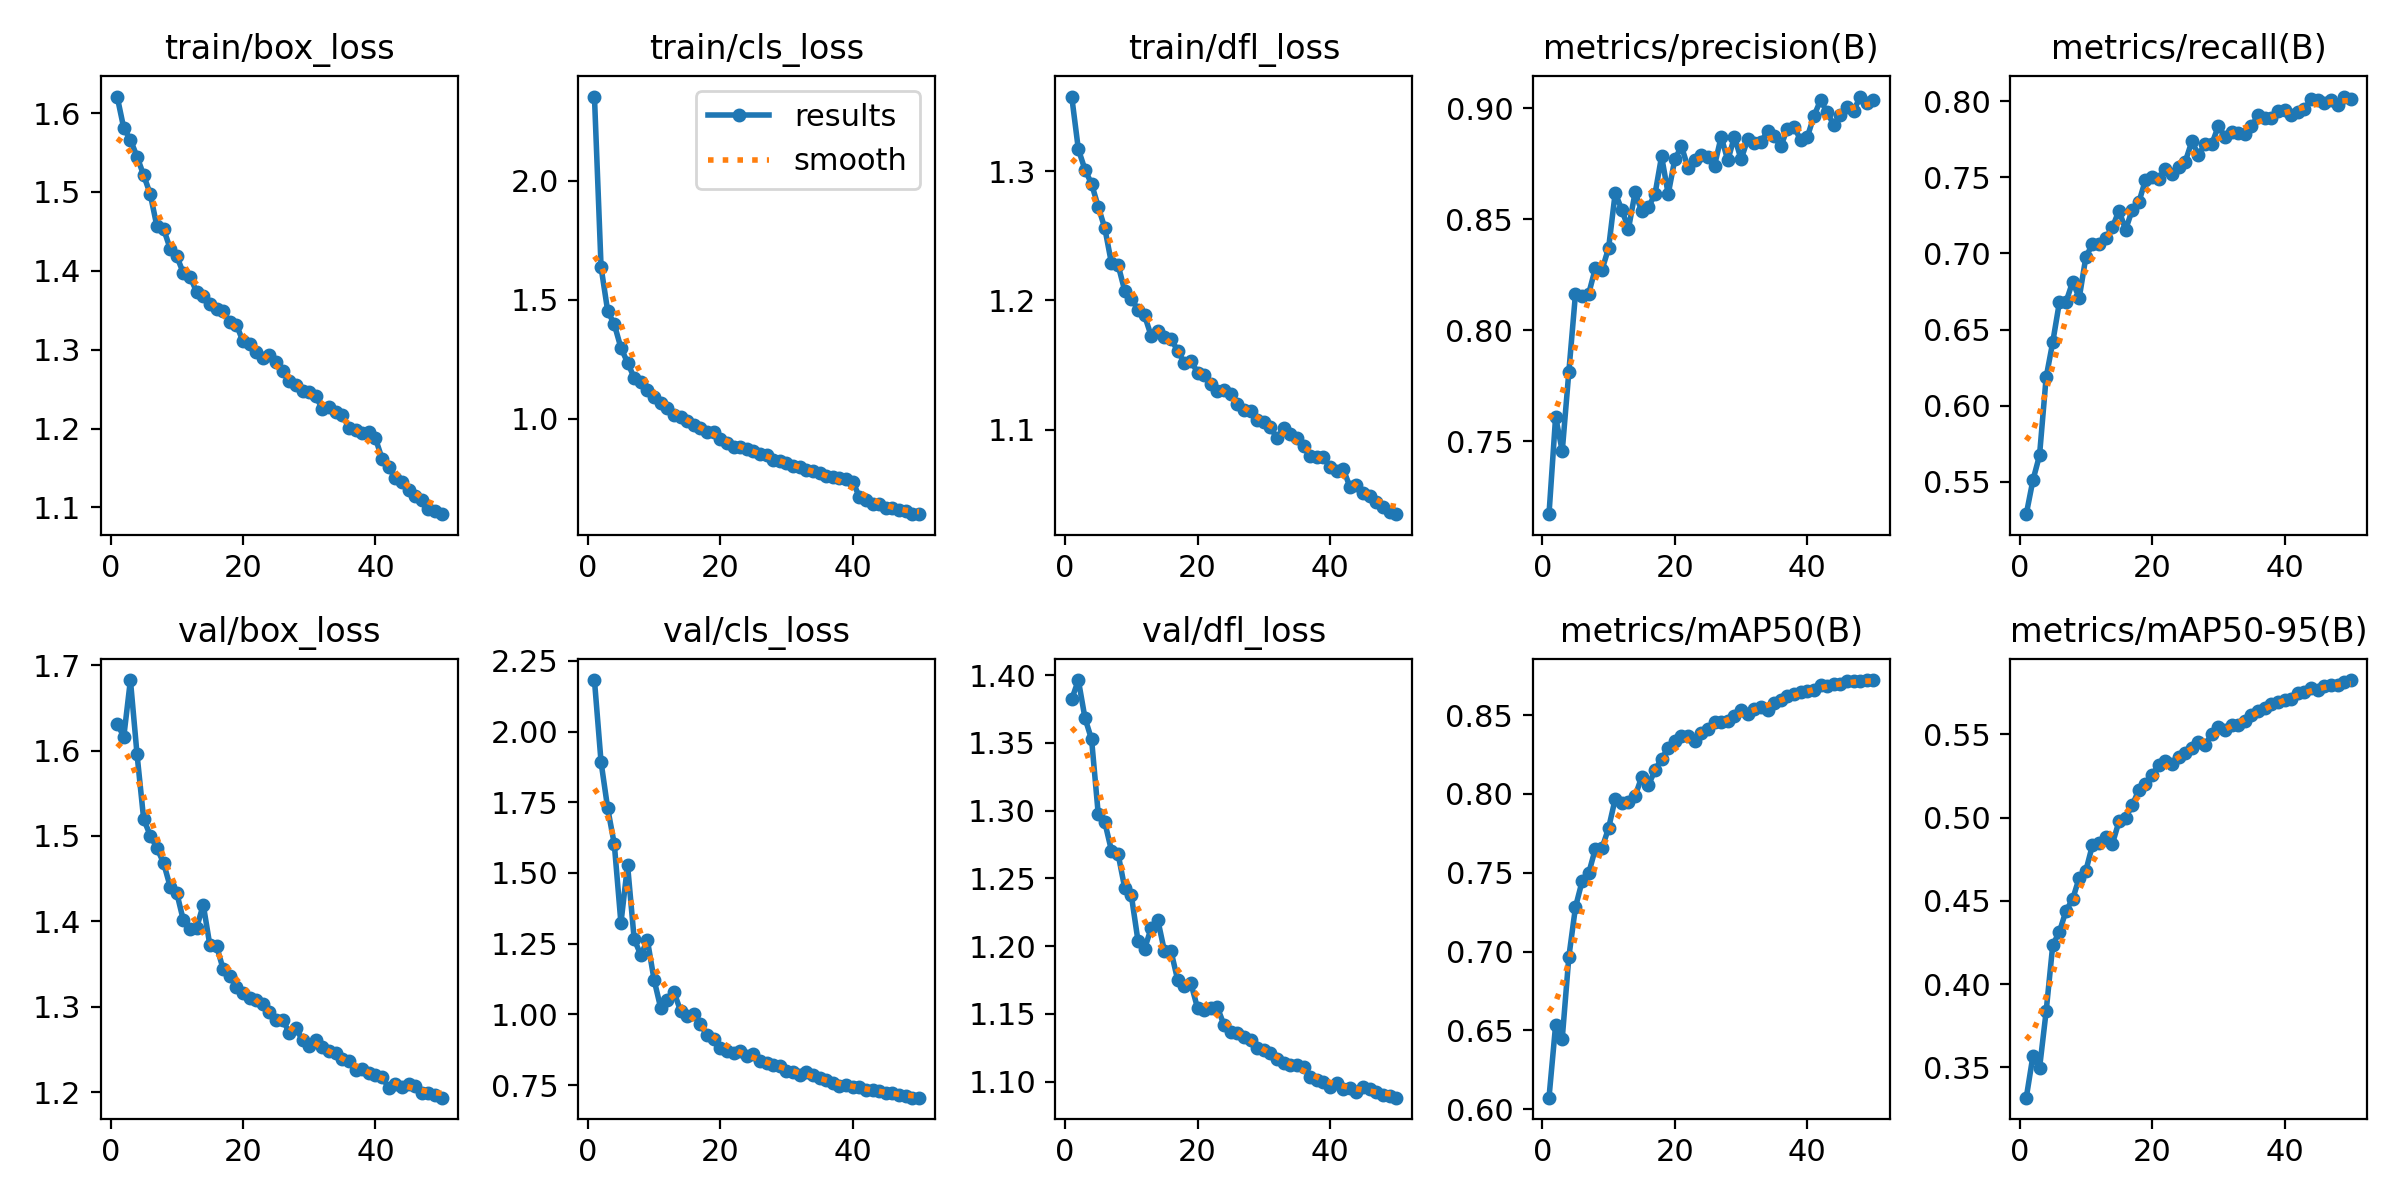

In [ ]:
# Kurva training
results_png = TRAIN_RUN_DIR / "results.png"

if results_png.exists():
    from IPython.display import display, Image
    display(Image(filename=str(results_png)))
else:
    print("results.png tidak ditemukan.")


## 10. Evaluasi final pada TEST SET

Kami menggunakan test set hanya untuk evaluasi final setelah training. Metrik utama: Precision, Recall, F1, mAP@50, dan mAP@50-95.


In [ ]:
best_model = YOLO(str(FINAL_BEST))

test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RESULTS_DIR),
    name="test_evaluation",
    exist_ok=True,
    plots=True,
    verbose=True
)

precision = float(test_metrics.box.mp)
recall = float(test_metrics.box.mr)
map50 = float(test_metrics.box.map50)
map5095 = float(test_metrics.box.map)

f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0
    else 0.0
)

metrics_summary = {
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "mAP50": map50,
    "mAP50_95": map5095
}

print(json.dumps(metrics_summary, indent=2))

(RESULTS_DIR / "test_metrics.json").write_text(
    json.dumps(metrics_summary, indent=2),
    encoding="utf-8"
)


Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.3 ms, read: 9.0±1.7 MB/s, size: 41.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/ppe-dataset/Dataset_no_person_glasses/test/labels... 1177 images, 158 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1177/1177 183.1it/s 6.4s
WARNING ⚠️ val: Cache directory /kaggle/input/ppe-dataset/Dataset_no_person_glasses/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 5.5it/s 13.5s
                   all       1177       3751      0.894      0.797       0.86      0.576
                Helmet        450        859      0.919      0.784      0.839      0.548
        

162

,class_id,class,mAP50_95
0,0,Helmet,0.5481
1,1,Mask,0.6470
2,2,Safety Vest,0.5997
3,3,boots,0.5674
4,4,glove,0.5186


confusion_matrix.png


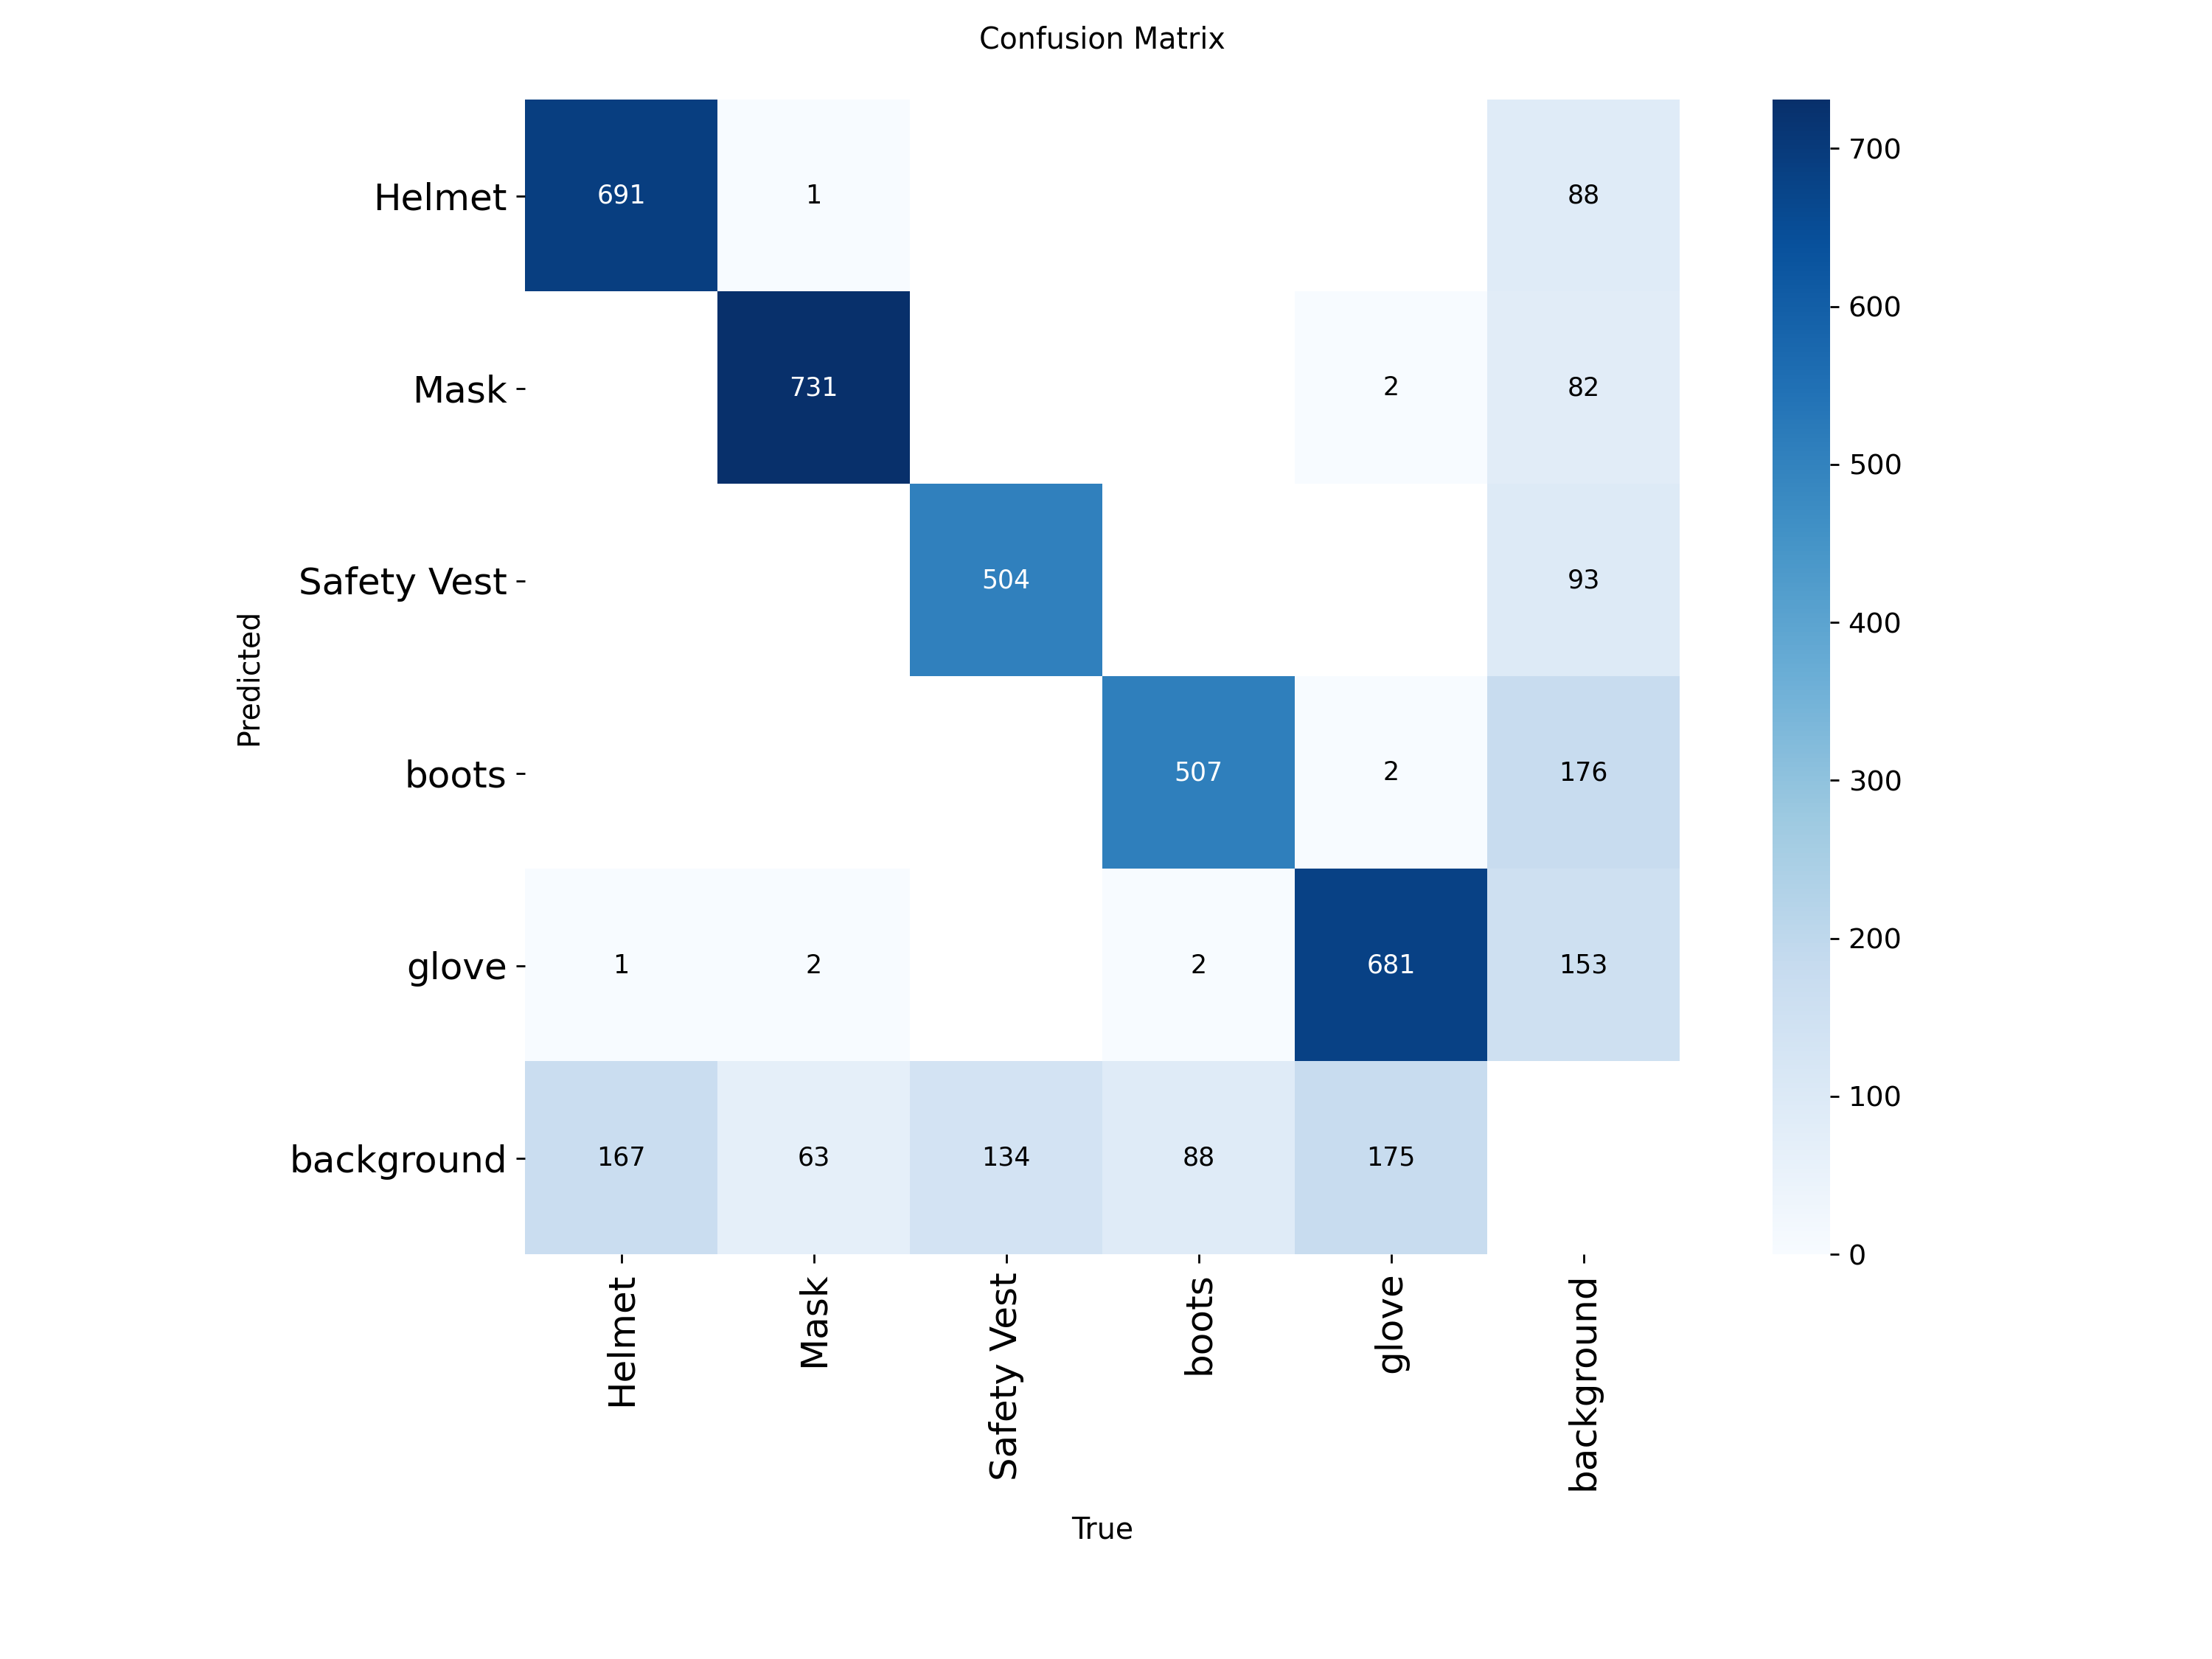

In [ ]:
# Per-class mAP dan plot evaluasi
per_class_maps = list(test_metrics.box.maps)

per_class_df = pd.DataFrame({
    "class_id": list(names.keys())[:len(per_class_maps)],
    "class": [names[i] for i in list(names.keys())[:len(per_class_maps)]],
    "mAP50_95": per_class_maps
})

display(
    per_class_df.style.format({
        "mAP50_95": "{:.4f}"
    })
)

TEST_RUN_DIR = Path(test_metrics.save_dir)

for filename in [
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]:
    path = TEST_RUN_DIR / filename

    if path.exists():
        print(filename)
        display(Image(filename=str(path)))


## 11. Inference pada gambar test


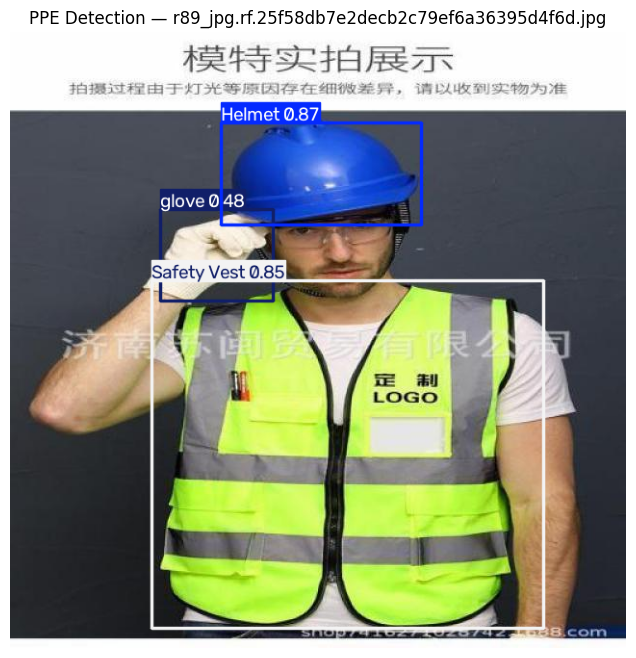

In [ ]:
test_pool = [
    p for p in TEST_IMAGES.rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

sample_image = random.choice(test_pool)

prediction = best_model.predict(
    source=str(sample_image),
    imgsz=IMG_SIZE,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    device=DEVICE,
    verbose=False
)[0]

annotated = prediction.plot()

plt.figure(figsize=(13, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"PPE Detection — {sample_image.name}")
plt.show()


## 12. Ringkasan objek PPE yang terdeteksi

Karena kelas `Person` tidak tersedia, analisis di sini kami batasi pada jumlah objek APD yang terdeteksi per kelas; kami tidak menyimpulkan status kepatuhan per pekerja.


In [ ]:
def detection_summary(result):
    if result.boxes is None or len(result.boxes) == 0:
        return pd.DataFrame(
            columns=["class_id", "class", "confidence"]
        )

    class_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    rows = [
        {
            "class_id": int(cls_id),
            "class": names[int(cls_id)],
            "confidence": float(conf)
        }
        for cls_id, conf in zip(class_ids, confs)
    ]

    return pd.DataFrame(rows)

detected_df = detection_summary(prediction)

if len(detected_df):
    summary = (
        detected_df
        .groupby("class")
        .agg(
            detections=("class", "count"),
            mean_confidence=("confidence", "mean")
        )
        .sort_values("detections", ascending=False)
    )

    display(
        summary.style.format({
            "mean_confidence": "{:.4f}"
        })
    )
else:
    print("Tidak ada objek PPE yang terdeteksi.")


,detections,mean_confidence
class,,
Helmet,1,0.8722
Safety Vest,1,0.8526
glove,1,0.4802


## 13. Export ONNX untuk Edge AI

Kami memakai ONNX sebagai format deployment, dengan ekspor melalui `model.export(format="onnx")` dari Ultralytics.


In [ ]:
ONNX_DIR = MODEL_DIR / "onnx"
ONNX_DIR.mkdir(parents=True, exist_ok=True)

generated_onnx = best_model.export(
    format="onnx",
    imgsz=IMG_SIZE,
    dynamic=False,
    simplify=True,
    nms=True
)

generated_onnx = Path(generated_onnx)

ONNX_FP32 = ONNX_DIR / "ppe_yolov8n_kaggle_fp32.onnx"
shutil.copy2(generated_onnx, ONNX_FP32)

print("ONNX FP32:", ONNX_FP32)


Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (6.0 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 10 packages in 267ms
Prepared 2 packages in 29ms
Installed 2 packages in 5ms
 + colorama==0.4.6
 + onnxslim==0.1.97

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.23.1 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: 

In [ ]:
ONNX_FP16 = None

if HAS_GPU:
    try:
        generated_fp16 = best_model.export(
            format="onnx",
            imgsz=IMG_SIZE,
            dynamic=False,
            simplify=True,
            nms=True,
            half=True
        )

        generated_fp16 = Path(generated_fp16)

        ONNX_FP16 = ONNX_DIR / "ppe_yolov8n_kaggle_fp16.onnx"
        shutil.copy2(generated_fp16, ONNX_FP16)

        print("ONNX FP16:", ONNX_FP16)

    except Exception as e:
        print("FP16 export dilewati:", repr(e))
else:
    print("GPU tidak tersedia; FP16 export dilewati.")


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (6.0 MB)

ONNX: starting export with onnx 1.23.1 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: converting to FP16...
ONNX: export success ✅ 2.6s, saved as '/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best.onnx' (5.9 MB)

Export complete (2.9s)
Results saved to /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/pp

## 14. INT8 Post-Training Quantization (PTQ)

Kami mengekspor model YOLOv8n terbaik ke ONNX INT8 untuk skenario Edge AI. Kalibrasi memakai dataset `val`: parameter `quantize=8` meminta INT8, sedangkan `data` dan `fraction` menyediakan data representatif untuk kalibrasi.

Set `RUN_INT8_EXPORT=False` bila hanya ingin menjalankan baseline/FP16.


In [ ]:
# INT8 ONNX export
ONNX_INT8 = None
INT8_EXPORT_ERROR = None

if RUN_INT8_EXPORT:
    try:
        generated_int8 = best_model.export(
            format="onnx",
            imgsz=IMG_SIZE,
            dynamic=False,
            simplify=True,
            nms=True,
            quantize=8,
            data=str(DATA_YAML),
            split="val",
            fraction=0.25
        )
        generated_int8 = Path(generated_int8)
        ONNX_INT8 = ONNX_DIR / "ppe_yolov8n_kaggle_int8.onnx"
        shutil.copy2(generated_int8, ONNX_INT8)
        print("ONNX INT8:", ONNX_INT8)
    except Exception as e:
        INT8_EXPORT_ERROR = repr(e)
        print("INT8 export gagal/dilewati:", INT8_EXPORT_ERROR)
else:
    print("RUN_INT8_EXPORT=False -> INT8 export dilewati.")


Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (6.0 MB)

ONNX: starting export with onnx 1.23.1 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: collecting INT8 calibration images from 'data=/content/ppe_kaggle_runtime.yaml'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 134.6±40.6 MB/s, size: 48.7 KB)
val: Scanning /kaggle/input/ppe-dataset/Dataset_no_person_glasses/val/labels... 589 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 589/589 581.8it/s 1.0s
WARNING ⚠️ val: Cache directory /kaggle/input/ppe-dataset/Dataset_no_person_glasses/val is not writable, cache not saved.
ONNX: quantizing INT8 with ONNX Runtime...


ONNX: export success ✅ 135.2s, saved as '/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best_int8.onnx' (3.3 MB)

Export complete (135.4s)
Results saved to /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best_int8.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best_int8.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best_int8.onnx imgsz=640 data=/content/ppe_kaggle_runtime.yaml  
Visualize:       https://netron.app
ONNX INT8: /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_int8.onnx


## 15. Evaluasi Model INT8

Kami mengevaluasi model INT8 pada `test` apabila ONNX INT8 berhasil dibuat, lalu membandingkannya dengan baseline FP32 berdasarkan Precision, Recall, F1, mAP50, dan mAP50-95.


In [ ]:
int8_metrics_summary = None

if ONNX_INT8 is not None and ONNX_INT8.exists():
    try:
        int8_model = YOLO(str(ONNX_INT8))
        int8_metrics = int8_model.val(
            data=str(DATA_YAML),
            split="test",
            imgsz=IMG_SIZE,
            batch=1,
            device=DEVICE,
            project=str(RESULTS_DIR),
            name="test_int8",
            exist_ok=True,
            plots=True,
            verbose=True
        )
        p8 = float(int8_metrics.box.mp)
        r8 = float(int8_metrics.box.mr)
        m50_8 = float(int8_metrics.box.map50)
        m95_8 = float(int8_metrics.box.map)
        f1_8 = 2 * p8 * r8 / (p8 + r8) if p8 + r8 > 0 else 0.0
        int8_metrics_summary = {
            "precision": p8, "recall": r8, "f1": f1_8,
            "mAP50": m50_8, "mAP50_95": m95_8
        }
        print(json.dumps(int8_metrics_summary, indent=2))
        (RESULTS_DIR / "test_metrics_int8.json").write_text(
            json.dumps(int8_metrics_summary, indent=2), encoding="utf-8"
        )
    except Exception as e:
        print("Evaluasi INT8 gagal/dilewati:", repr(e))
else:
    print("Model INT8 tidak tersedia; evaluasi dilewati.")


Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_int8.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 5 packages in 181ms
Prepared 1 package in 2.99s
Installed 1 package in 51ms
 + onnxruntime-gpu==1.30.0

requirements: AutoUpdate success ✅ 3.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.30.0 with CPUExecutionProvider
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.4±0.7 ms, read: 146.4±20.4 MB/s, size: 46.5 KB)
val: Scanning /kaggle/input/ppe-dataset/Dataset_no_person_glasses/test/labels... 1177 images, 158 backgrounds, 0 corrupt: 100% ━━━━━━━

## 16. Pruning Bobot 30% + Evaluasi

Kami menerapkan pruning dengan `torch.nn.utils.prune` pada bobot layer `Conv2d`. Metode ini adalah **unstructured pruning**, sehingga shape layer tetap. Karena itu kami mengukur sparsity secara eksplisit dan tidak mengasumsikan adanya pengurangan ukuran file atau latency. Setelah pruning, kami mencoba fine-tuning singkat.


In [ ]:
from torch.nn.utils import prune

PRUNED_INITIAL_PT = MODEL_DIR / "ppe_yolov8n_kaggle_pruned_initial.pt"
PRUNED_BEST_PT = MODEL_DIR / "ppe_yolov8n_kaggle_pruned_finetuned.pt"
pruned_model = None
pruning_status = {
    "enabled": RUN_PRUNING,
    "amount": PRUNE_AMOUNT,
    "sparsity": None,
    "finetune": "not_run"
}

def global_conv_sparsity(torch_model):
    total = 0
    zero = 0
    for module in torch_model.modules():
        if isinstance(module, torch.nn.Conv2d):
            w = module.weight.detach()
            total += w.numel()
            zero += int(torch.count_nonzero(w == 0).item())
    return zero / total if total else 0.0

if RUN_PRUNING:
    try:
        pruned_model = YOLO(str(FINAL_BEST))
        parameters_to_prune = []
        for module_name, module in pruned_model.model.named_modules():
            if isinstance(module, torch.nn.Conv2d) and "dfl" not in module_name.lower():
                parameters_to_prune.append((module, "weight"))

        if not parameters_to_prune:
            raise RuntimeError("Tidak ada Conv2d yang dapat dipruning.")

        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=PRUNE_AMOUNT
        )

        for module, parameter_name in parameters_to_prune:
            try:
                prune.remove(module, parameter_name)
            except ValueError:
                pass

        sparsity_value = global_conv_sparsity(pruned_model.model)
        pruning_status["sparsity"] = float(sparsity_value)
        pruned_model.save(str(PRUNED_INITIAL_PT))
        print(f"Global Conv2d sparsity: {sparsity_value * 100:.2f}%")
        print("Pruned initial model:", PRUNED_INITIAL_PT)

        pruned_val = pruned_model.val(
            data=str(DATA_YAML), split="test", imgsz=IMG_SIZE,
            batch=BATCH_SIZE, device=DEVICE, project=str(RESULTS_DIR),
            name="test_pruned_initial", exist_ok=True, plots=True, verbose=True
        )
        pp = float(pruned_val.box.mp)
        rr = float(pruned_val.box.mr)
        mm50 = float(pruned_val.box.map50)
        mm95 = float(pruned_val.box.map)
        pf1 = 2 * pp * rr / (pp + rr) if pp + rr > 0 else 0.0
        pruning_status["initial_metrics"] = {
            "precision": pp, "recall": rr, "f1": pf1,
            "mAP50": mm50, "mAP50_95": mm95
        }

        # Fine-tuning singkat. Jika runtime Ultralytics tidak kompatibel dengan
        # state hasil pruning, error ditangkap agar notebook tetap lanjut.
        try:
            pruning_train = pruned_model.train(
                data=str(DATA_YAML), epochs=PRUNE_FINETUNE_EPOCHS, imgsz=IMG_SIZE,
                batch=BATCH_SIZE, device=DEVICE, workers=2, patience=5,
                lr0=0.001, pretrained=False, project=str(RUNS_DIR),
                name="yolov8n_ppe_pruned_finetune", exist_ok=True, plots=True, verbose=True
            )
            candidate = Path(pruning_train.save_dir) / "weights" / "best.pt"
            if candidate.exists():
                shutil.copy2(candidate, PRUNED_BEST_PT)
                pruning_status["finetune"] = "success"
                pruning_status["finetuned_path"] = str(PRUNED_BEST_PT)
                print("Pruned fine-tuned model:", PRUNED_BEST_PT)
            else:
                pruning_status["finetune"] = "completed_but_best_not_found"
        except Exception as ft_e:
            pruning_status["finetune"] = f"failed: {repr(ft_e)}"
            print("Fine-tuning pruning gagal/dilewati:", repr(ft_e))

    except Exception as e:
        pruning_status["finetune"] = f"pruning_failed: {repr(e)}"
        print("Pruning gagal/dilewati:", repr(e))
else:
    print("RUN_PRUNING=False -> pruning dilewati.")

(RESULTS_DIR / "pruning_status.json").write_text(
    json.dumps(pruning_status, indent=2), encoding="utf-8"
)


Global Conv2d sparsity: 30.00%
Pruned initial model: /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_pruned_initial.pt
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 104.0±32.4 MB/s, size: 46.5 KB)
val: Scanning /kaggle/input/ppe-dataset/Dataset_no_person_glasses/test/labels... 1177 images, 158 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1177/1177 645.8it/s 1.8s
WARNING ⚠️ val: Cache directory /kaggle/input/ppe-dataset/Dataset_no_person_glasses/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 5.5it/s 13.6s
                   all       1177       3751      0.885      0.775      0.847      0.561
                Helmet        450        859      0.916      0.758      0.821      0.535
         

427

## 17. Benchmark Ukuran Model & Latency Hasil Optimasi

Kami melakukan benchmark dengan alur `Ultralytics predict` end-to-end pada satu gambar contoh untuk baseline dan setiap varian optimasi YOLOv8n. Hasilnya sangat bergantung pada GPU/CPU, versi runtime, dan ukuran input, sehingga kami mencatatnya untuk lingkungan saat eksperimen dijalankan.


In [ ]:
def size_mb(path):
    p = Path(path)
    return p.stat().st_size / (1024 ** 2) if p.exists() else None

def benchmark_latency(model_source, repeats=BENCHMARK_REPEATS, warmup=BENCHMARK_WARMUP):
    mdl = YOLO(str(model_source))
    for _ in range(warmup):
        mdl.predict(source=str(sample_image), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        mdl.predict(source=str(sample_image), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
        times.append((time.perf_counter() - t0) * 1000)
    return {
        "latency_mean_ms": float(np.mean(times)),
        "latency_median_ms": float(np.median(times)),
        "latency_p95_ms": float(np.percentile(times, 95)),
    }

benchmark_rows = []

def add_benchmark_row(label, path):
    if path is None or not Path(path).exists():
        return
    try:
        row = {"model": label, "path": str(path), "size_MB": size_mb(path)}
        row.update(benchmark_latency(path))
        benchmark_rows.append(row)
        print(row)
    except Exception as e:
        print(f"Benchmark {label} gagal:", repr(e))

add_benchmark_row("YOLOv8n FP32 PT", FINAL_BEST)
add_benchmark_row("YOLOv8n FP32 ONNX", ONNX_FP32)
add_benchmark_row("YOLOv8n FP16 ONNX", ONNX_FP16)
add_benchmark_row("YOLOv8n INT8 ONNX", ONNX_INT8)
pruned_for_benchmark = PRUNED_BEST_PT if PRUNED_BEST_PT.exists() else PRUNED_INITIAL_PT
add_benchmark_row("YOLOv8n Pruned", pruned_for_benchmark)

benchmark_df = pd.DataFrame(benchmark_rows)
if not benchmark_df.empty:
    display(benchmark_df)
    benchmark_df.to_csv(RESULTS_DIR / "benchmark_all_models.csv", index=False)
    (RESULTS_DIR / "benchmark_all_models.json").write_text(
        benchmark_df.to_json(orient="records", indent=2), encoding="utf-8"
    )
else:
    print("Belum ada artefak yang berhasil dibenchmark.")


{'model': 'YOLOv8n FP32 PT', 'path': '/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best.pt', 'size_MB': 5.962686538696289, 'latency_mean_ms': 12.039596599970537, 'latency_median_ms': 11.822728999504761, 'latency_p95_ms': 13.383188049192542}
Loading /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.30.0 with CPUExecutionProvider
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
{'model': 'YOLOv8n FP32 ONNX', 'path': '/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_fp32.onnx', 'size_MB': 11.726591110229492, 'latency_mean_ms': 102.1921046000898, 'latency_median_ms': 101.00586150019808, 'latency_p95_ms': 114.42870955006583}
Loading /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_fp16.onnx for ONNX Runtime infere

,model,path,size_MB,latency_mean_ms,latency_median_ms,latency_p95_ms
0,YOLOv8n FP32 PT,/content/drive/MyDrive/Deep_Learning/PPE_Proje...,5.962687,12.039597,11.822729,13.383188
1,YOLOv8n FP32 ONNX,/content/drive/MyDrive/Deep_Learning/PPE_Proje...,11.726591,102.192105,101.005862,114.428710
2,YOLOv8n FP16 ONNX,/content/drive/MyDrive/Deep_Learning/PPE_Proje...,5.908933,107.580370,96.858872,135.231106
3,YOLOv8n INT8 ONNX,/content/drive/MyDrive/Deep_Learning/PPE_Proje...,3.272139,195.676169,171.002280,257.677978
4,YOLOv8n Pruned,/content/drive/MyDrive/Deep_Learning/PPE_Proje...,5.957865,11.347975,11.108469,12.184423


## 18. Tabel Ringkasan Optimasi

Tabel berikut merangkum metrik pada test set dan ukuran berkas setiap varian; seluruh nilainya kami hitung dari hasil eksekusi sel sebelumnya.


In [ ]:
summary_rows = []

def add_metric_row(name, metrics, path=None):
    if not metrics:
        return
    summary_rows.append({
        "model": name,
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "f1": metrics.get("f1"),
        "mAP50": metrics.get("mAP50"),
        "mAP50_95": metrics.get("mAP50_95"),
        "size_MB": size_mb(path) if path and Path(path).exists() else None
    })

add_metric_row("YOLOv8n FP32 baseline", metrics_summary, FINAL_BEST)
add_metric_row("YOLOv8n INT8 ONNX", int8_metrics_summary, ONNX_INT8)
add_metric_row("YOLOv8n Pruned", pruning_status.get("initial_metrics"), PRUNED_INITIAL_PT)

optimization_df = pd.DataFrame(summary_rows)
if not optimization_df.empty:
    display(optimization_df)
    optimization_df.to_csv(RESULTS_DIR / "optimization_summary.csv", index=False)
    (RESULTS_DIR / "optimization_summary.json").write_text(
        optimization_df.to_json(orient="records", indent=2), encoding="utf-8"
    )

print("Status INT8:", "OK" if ONNX_INT8 is not None else "BELUM TERBUAT")
print("Status pruning:", json.dumps(pruning_status, indent=2))


,model,precision,recall,f1,mAP50,mAP50_95,size_MB
0,YOLOv8n FP32 baseline,0.894203,0.797182,0.842910,0.860427,0.576166,5.962687
1,YOLOv8n INT8 ONNX,0.895224,0.775191,0.830895,0.792161,0.530769,3.272139
2,YOLOv8n Pruned,0.885403,0.774550,0.826275,0.846900,0.560738,5.987979


Status INT8: OK
Status pruning: {
  "enabled": true,
  "amount": 0.3,
  "sparsity": 0.2999987338465475,
  "finetune": "success",
  "initial_metrics": {
    "precision": 0.8854027346712934,
    "recall": 0.774549672936506,
    "f1": 0.826274771991862,
    "mAP50": 0.8469000808915024,
    "mAP50_95": 0.5607375447432547
  },
  "finetuned_path": "/content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_pruned_finetuned.pt"
}


## 19. Ringkasan dan keterbatasan

Dataset memiliki 5 kelas: Helmet, Mask, Safety Vest, boots, dan glove. Karena `Person` dihapus dari dataset, model kami tidak dapat mengaitkan objek PPE ke individu tertentu; keterbatasan ini kami bahas pada laporan.

Optimasi yang kami terapkan dalam notebook ini adalah transfer learning, early stopping, FP16 export, INT8 PTQ, pruning bobot, dan benchmark latency/ukuran model.

Catatan: pruning yang kami gunakan adalah **unstructured pruning**; sparsity meningkat tetapi shape tensor tidak berubah, sehingga kami tidak mengasumsikan pengurangan ukuran file/latency sebelum diukur. Untuk deployment edge, hasil benchmark pada hardware/runtime target lebih representatif.


In [ ]:
# Verifikasi artefak hasil
final_files = {
    "best.pt": FINAL_BEST,
    "last.pt": FINAL_LAST,
    "onnx_fp32": ONNX_FP32,
    "onnx_fp16": ONNX_FP16,
    "onnx_int8": ONNX_INT8,
    "pruned_initial.pt": PRUNED_INITIAL_PT,
    "pruned_finetuned.pt": PRUNED_BEST_PT,
    "test_metrics.json": RESULTS_DIR / "test_metrics.json",
    "test_metrics_int8.json": RESULTS_DIR / "test_metrics_int8.json",
    "pruning_status.json": RESULTS_DIR / "pruning_status.json",
    "optimization_summary.csv": RESULTS_DIR / "optimization_summary.csv",
    "benchmark_all_models.csv": RESULTS_DIR / "benchmark_all_models.csv"
}

for label, path in final_files.items():
    exists = Path(path).exists() if path is not None else False
    print(f"{label:28s} -> {'OK' if exists else 'BELUM ADA'} | {path}")

print("\nDataset temporary:")
print(KAGGLE_ROOT)
print("\nOutput persistent:")
print(PROJECT_DIR)


best.pt                      -> OK | /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_best.pt
last.pt                      -> OK | /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_last.pt
onnx_fp32                    -> OK | /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_fp32.onnx
onnx_fp16                    -> OK | /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_fp16.onnx
onnx_int8                    -> OK | /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/onnx/ppe_yolov8n_kaggle_int8.onnx
pruned_initial.pt            -> OK | /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_pruned_initial.pt
pruned_finetuned.pt          -> OK | /content/drive/MyDrive/Deep_Learning/PPE_Project_Kel_4/models_kaggle_ppe/ppe_yolov8n_kaggle_pruned_finetuned.p